In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load Dataset
file_path =("C:/Users/luvpa/Downloads/cleaned_merged_heart_dataset.csv")
data = pd.read_csv("C:/Users/luvpa/Downloads/cleaned_merged_heart_dataset.csv")

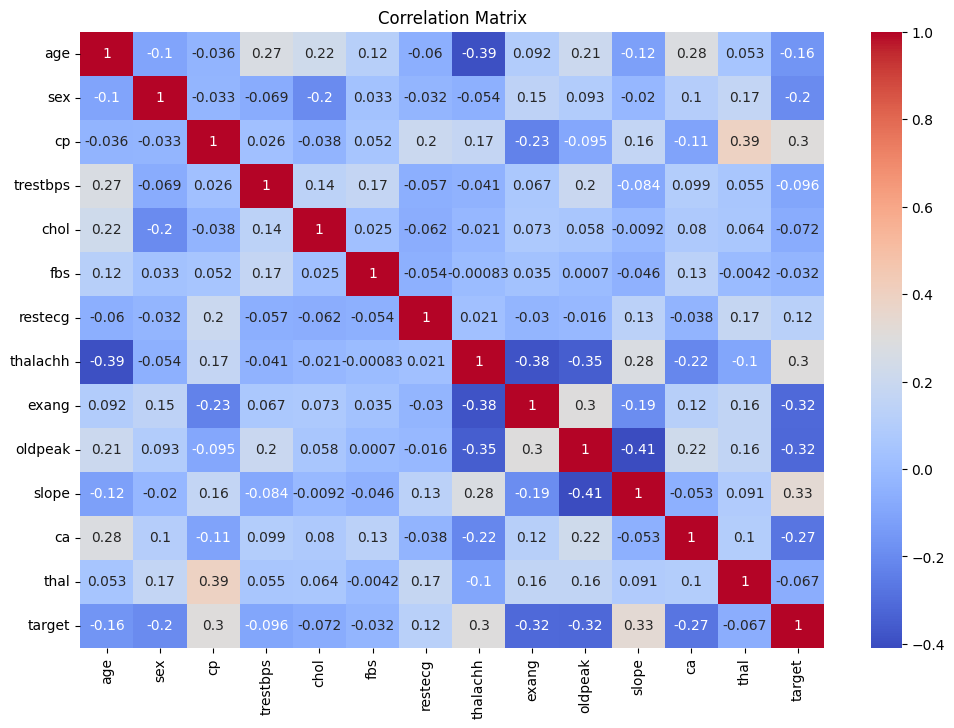

In [2]:
# Correlation Matrix
correlation_matrix = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_target_distribution(data, target_col):
    """
    Plots the distribution of a target column with counts and percentages.
    
    Parameters:
    - data: pandas DataFrame
    - target_col: str, name of the target column
    """
    if target_col not in data.columns:
        print(f"Column '{target_col}' not found in the dataset.")
        return
    
    # Count values
    counts = data[target_col].value_counts().sort_index()
    total = counts.sum()
    
    # Create a pastel color palette
    colors = sns.color_palette("pastel", len(counts))
    
    # Plot bar chart
    plt.figure(figsize=(8,5))
    bars = plt.bar(counts.index.astype(str), counts.values, color=colors)
    
    # Add percentages on top of bars
    for bar, count in zip(bars, counts.values):
        percentage = count / total * 100
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{percentage:.1f}%", ha='center', va='bottom')
    
    plt.xlabel(target_col)
    plt.ylabel("Count")
    plt.title(f"{target_col} Distribution")
    plt.show()


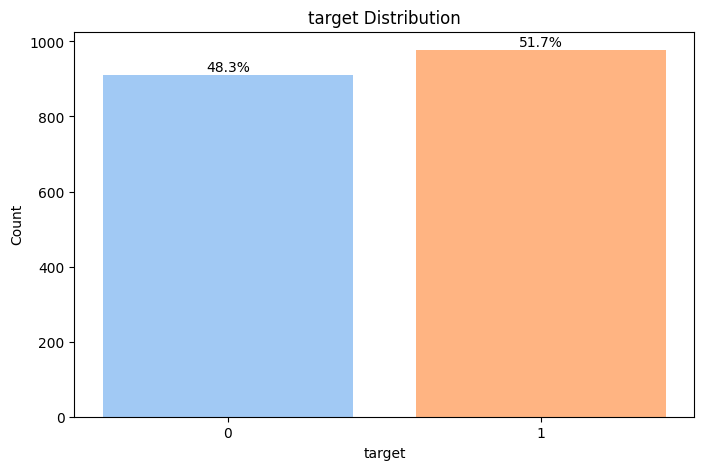

In [4]:
plot_target_distribution(data, 'target')

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


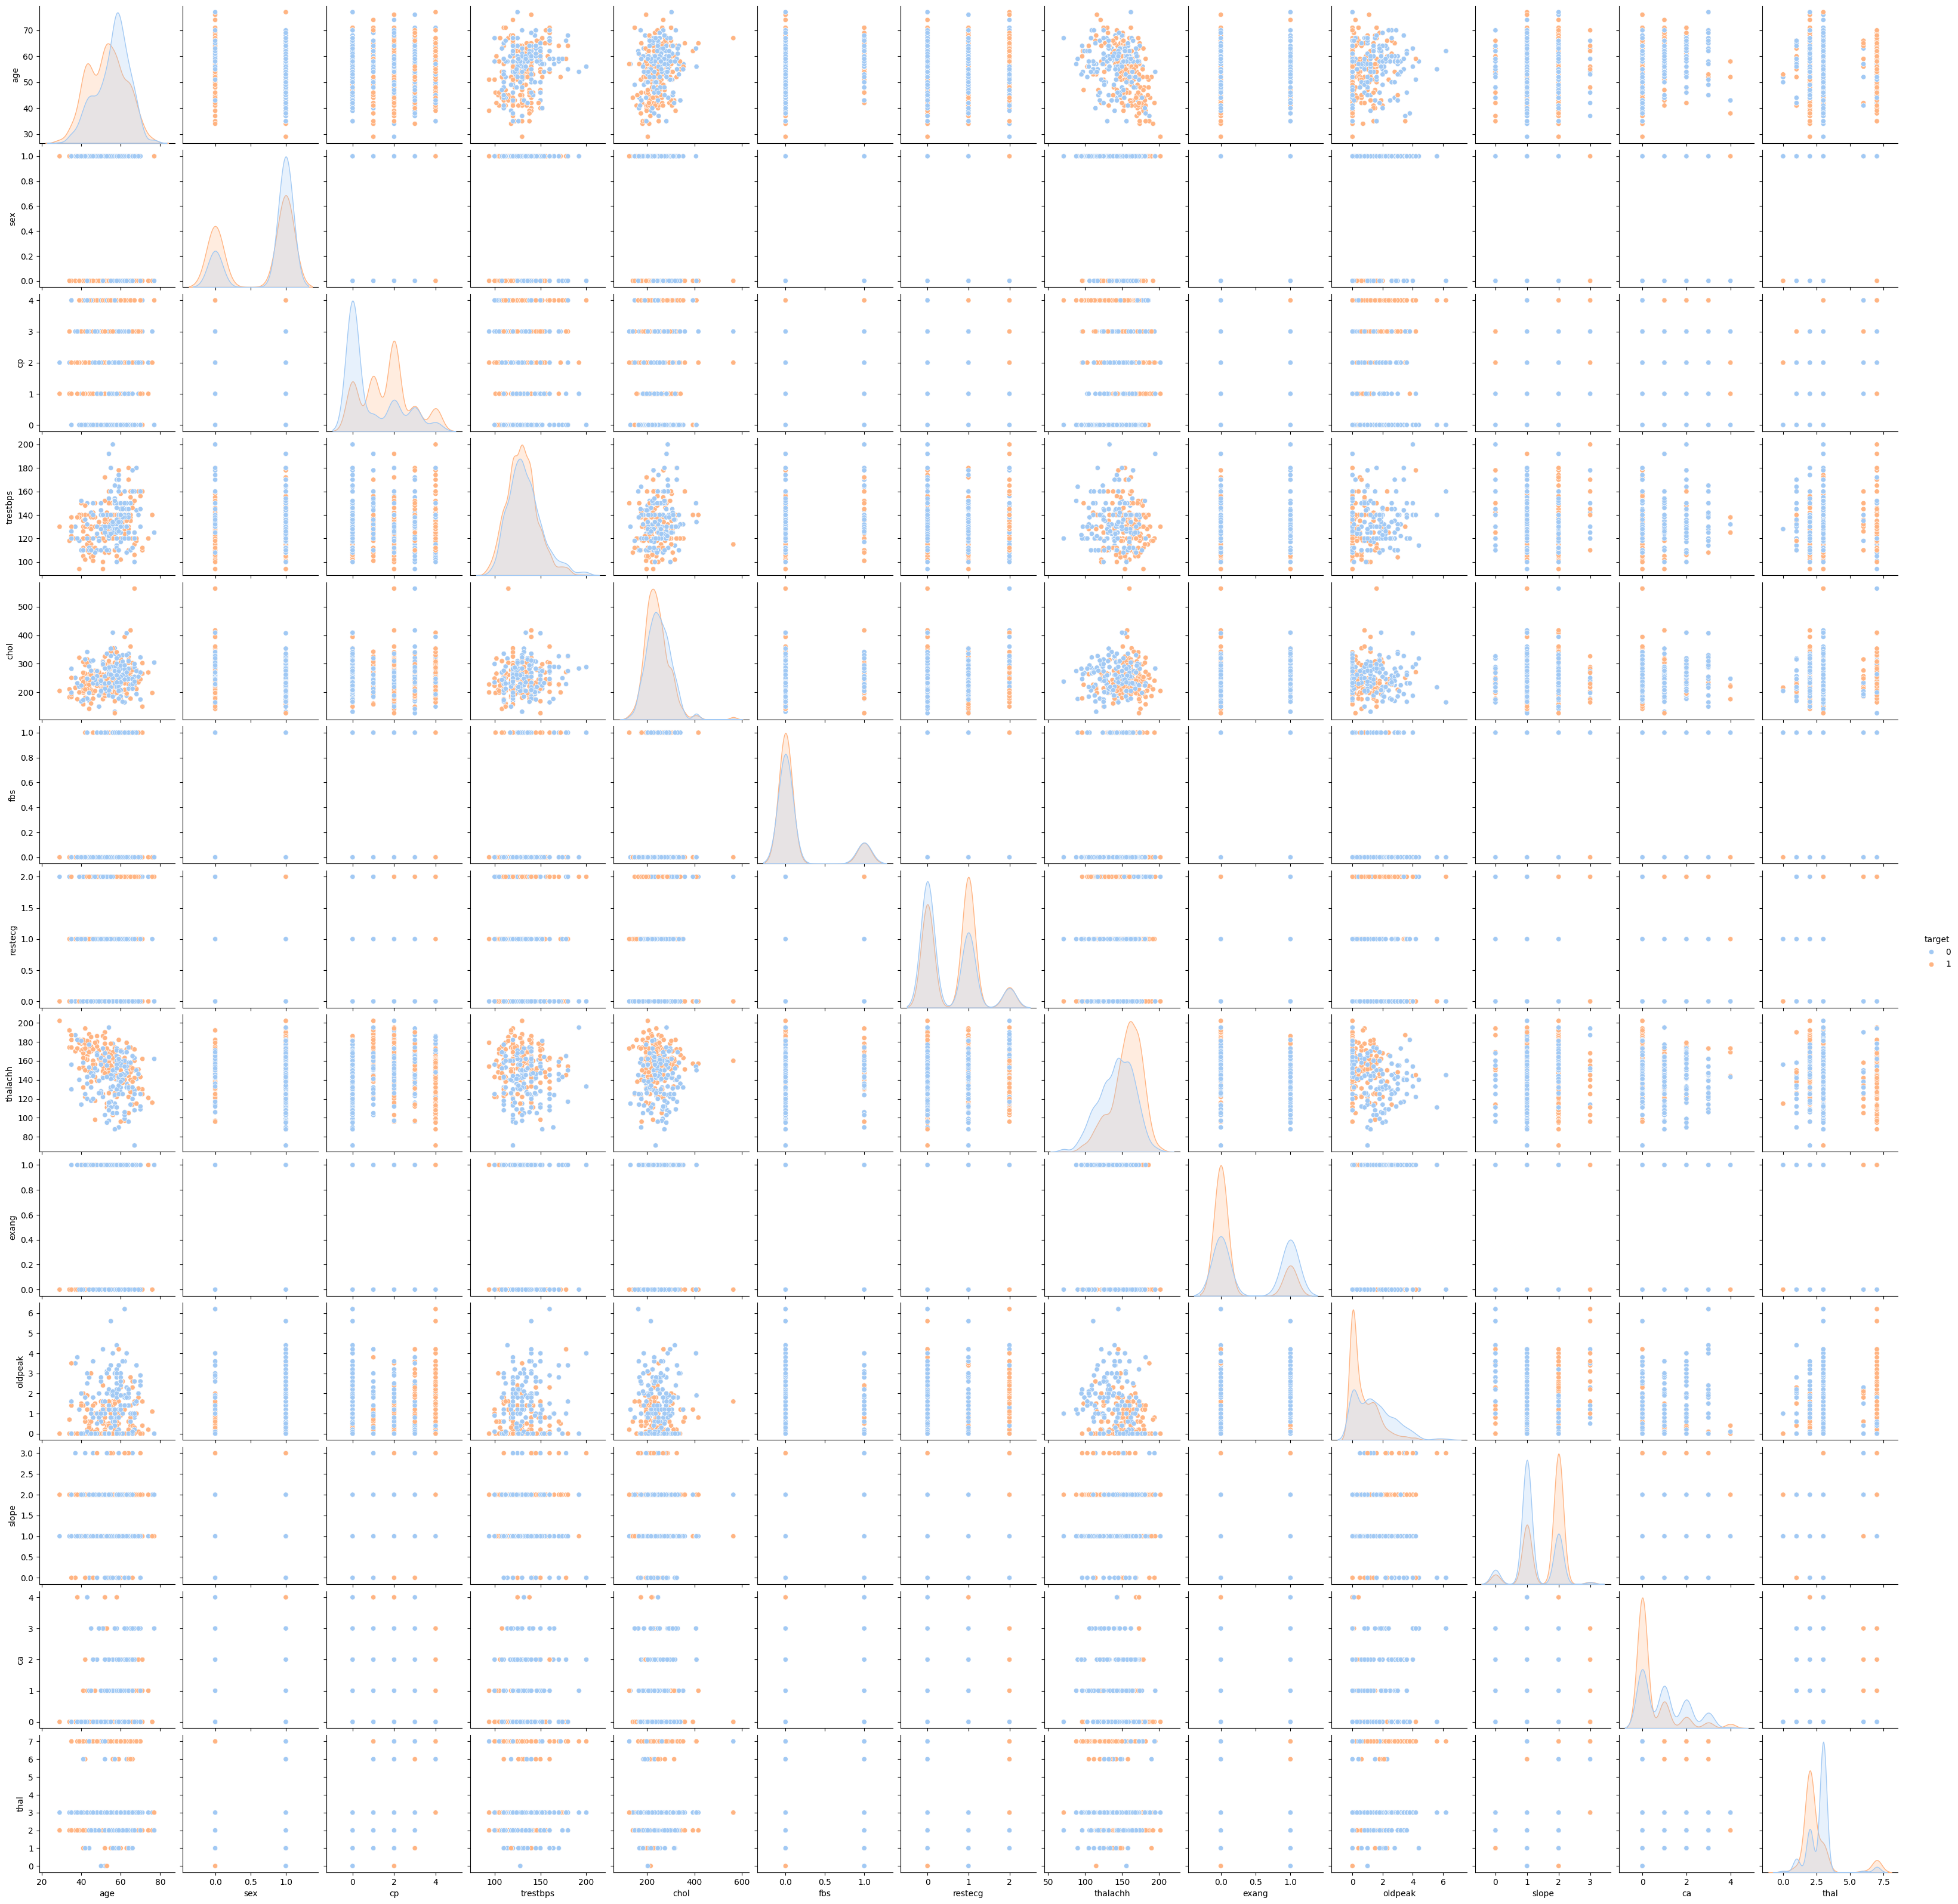

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define target column
target_col = 'target'

# Verify the column exists
print(data.columns)

# Pairplot for relationships between features, colored by target
sns.pairplot(data, diag_kind='kde', hue=target_col, palette='pastel')
plt.show()

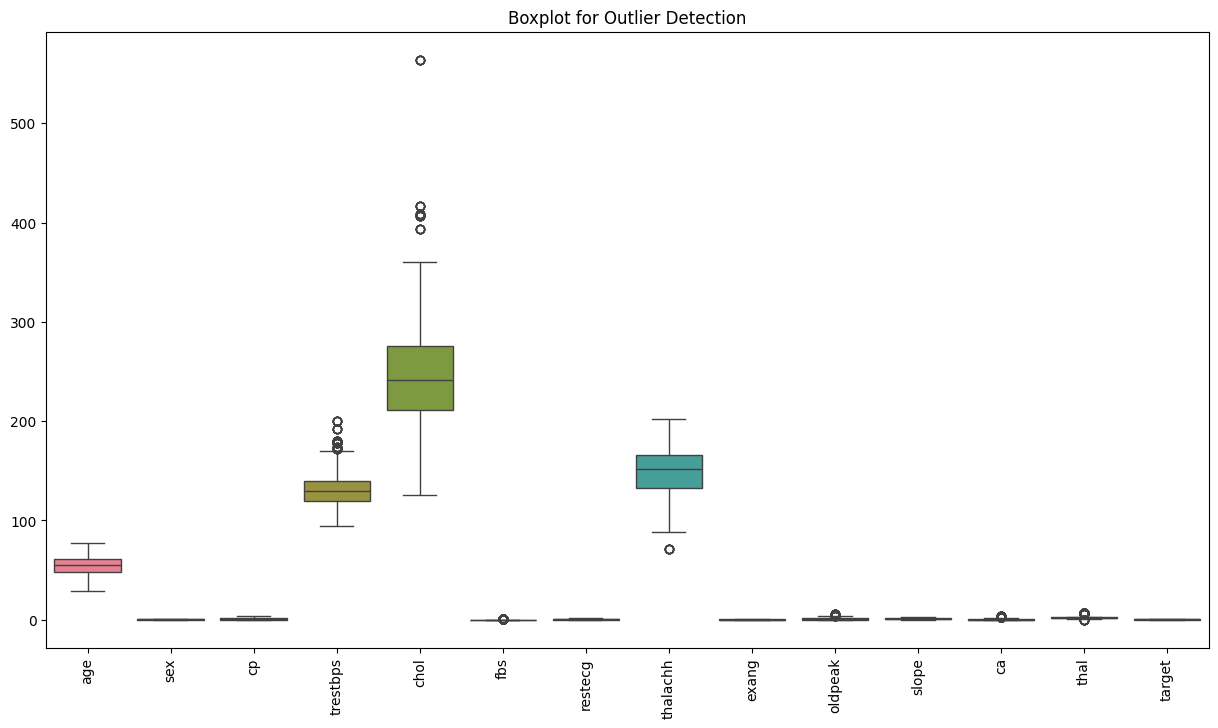

In [7]:
# Boxplots for Outlier Detection
plt.figure(figsize=(15, 8))
sns.boxplot(data=data)
plt.title('Boxplot for Outlier Detection')
plt.xticks(rotation=90)
plt.show()

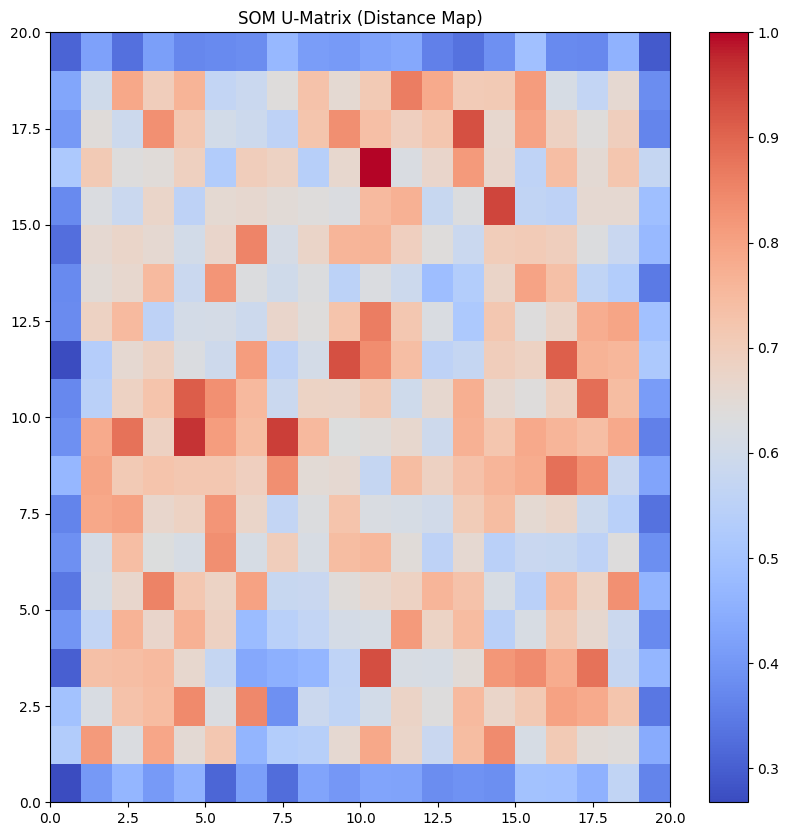

In [15]:
from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Select Features and Normalize the Dataset
features = data.drop(columns=[target_col])  # Exclude target column if it exists
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(features)
pca = PCA(n_components=0.95)  # Keep top components explaining most variance
data_scaled_pca = pca.fit_transform(data_scaled)

# Initialize and Train SOM
som = MiniSom(x=20, y=20, input_len=data_scaled_pca.shape[1], sigma=0.3, learning_rate=0.1)
som.random_weights_init(data_scaled_pca)
som.train_random(data_scaled_pca, num_iteration=10000)  

# Plot U-Matrix (Distance Map)
plt.figure(figsize=(10, 10))
plt.pcolor(som.distance_map().T, cmap='coolwarm')  # U-Matrix
plt.colorbar()
plt.title('SOM U-Matrix (Distance Map)')
plt.show()

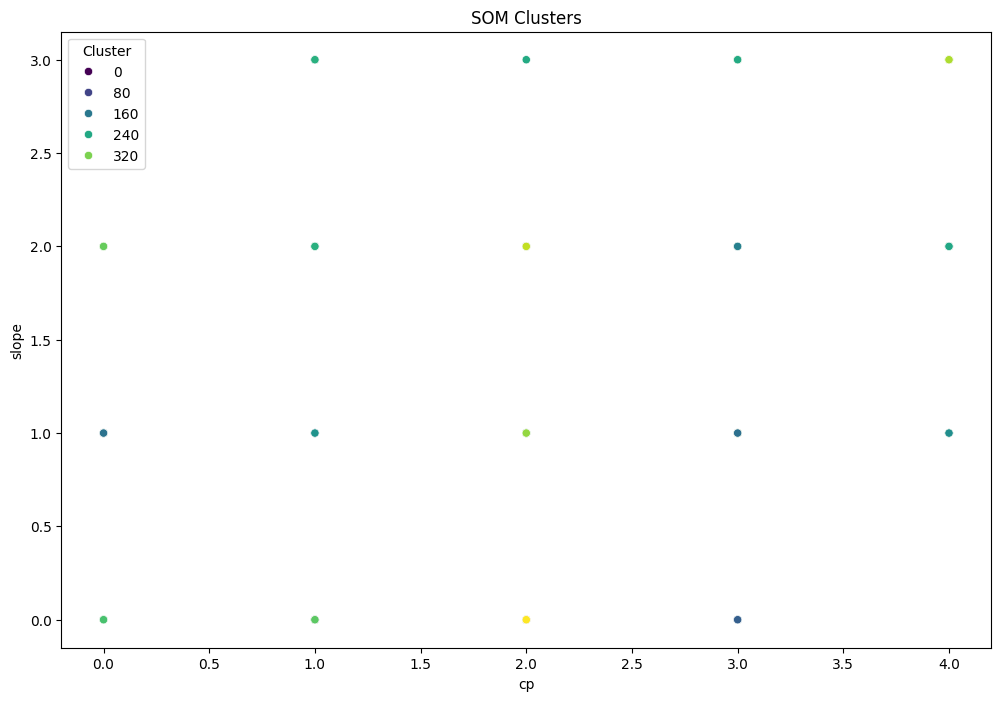

Silhouette Score: 0.69
Calinski-Harabasz Index: 173.38
Davies-Bouldin Index: 0.64


In [16]:
# Assign Clusters to Data Points
win_map = som.win_map(data_scaled_pca)
clusters = np.zeros(len(data_scaled_pca))

for i, x in enumerate(data_scaled_pca):
    winner = som.winner(x)  # Get the winning neuron
    clusters[i] = winner[0] * som._weights.shape[1] + winner[1]  # Assign unique cluster ID

# Add Clusters to the Original Data
data['Cluster'] = clusters.astype(int)

# Visualize Clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x='cp', y='slope', hue='Cluster', data=data, palette='viridis')
plt.title('SOM Clusters')
plt.show()

sil_score = silhouette_score(data_scaled_pca, data['Cluster'])
ch_score = calinski_harabasz_score(data_scaled_pca, data['Cluster'])
db_score = davies_bouldin_score(data_scaled_pca, data['Cluster'])
print(f"Silhouette Score: {sil_score:.2f}")
print(f"Calinski-Harabasz Index: {ch_score:.2f}")
print(f"Davies-Bouldin Index: {db_score:.2f}")

In [17]:
# Group the data by clusters and compute mean statistics
cluster_summary = data.groupby('Cluster').mean()
print(cluster_summary)

               age  sex   cp    trestbps        chol  fbs  restecg  \
Cluster                                                              
0        41.000000  0.0  1.0  130.000000  204.000000  0.0      0.0   
1        64.000000  0.0  0.0  180.000000  325.000000  0.0      1.0   
2        52.000000  1.0  3.0  152.000000  298.000000  1.0      1.0   
3        59.588235  1.0  0.0  137.647059  250.764706  0.0      0.0   
5        54.000000  0.0  2.0  110.000000  214.000000  0.0      1.0   
...            ...  ...  ...         ...         ...  ...      ...   
395      43.000000  1.0  0.0  132.000000  247.000000  1.0      0.0   
396      34.000000  0.0  1.0  118.000000  210.000000  0.0      1.0   
397      53.333333  1.0  0.0  110.000000  239.000000  0.0      1.0   
398      41.000000  1.0  1.0  110.000000  235.000000  0.0      1.0   
399      42.000000  1.0  2.0  120.000000  240.000000  1.0      1.0   

           thalachh  exang   oldpeak  slope        ca  thal  target  
Cluster            

In [18]:
# Assuming 'target_col' contains the true labels
cluster_vs_target = pd.crosstab(data['Cluster'], data[target_col])
print(cluster_vs_target)

target    0  1
Cluster       
0         0  5
1         0  5
2         0  5
3        17  0
5         0  5
...      .. ..
395       4  0
396       0  5
397       6  0
398       0  5
399       0  5

[306 rows x 2 columns]


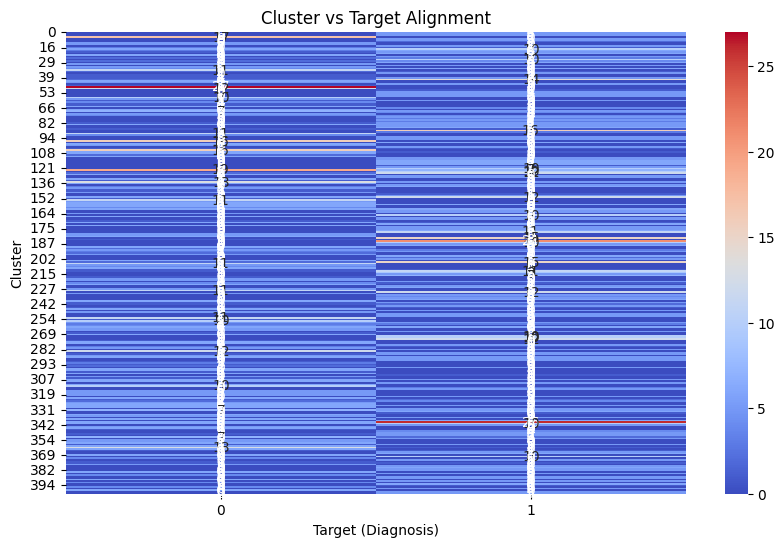

In [19]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_vs_target, annot=True, fmt='d', cmap='coolwarm')
plt.title('Cluster vs Target Alignment')
plt.xlabel('Target (Diagnosis)')
plt.ylabel('Cluster')
plt.show()